## 2. The Architecture: Attention and Wavelets
Standard Physics-Informed Neural Networks (PINNs) suffer from **Spectral Bias**—they naturally prefer learning low-frequency, smooth functions. The HH equations, however, are dominated by high-frequency, violent voltage spikes. If a standard MLP tries to learn this, it will either smooth out the spike or oscillate uncontrollably. 

We solve this using a two-pronged architectural approach:

### A. Global Temporal Awareness (Self-Attention)
The Transformer's Self-Attention mechanism computes how every single time point relates to every other time point in the sequence:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$
This allows the network to instantly correlate the slow buildup of the gating variables at $t=10$ms with the explosive voltage spike at $t=35$ms, entirely bypassing the need for an ODE solver.

### B. The Anti-Stiffness Weapon (Mexican Hat Wavelet)
To defeat Spectral Bias, we replace standard global activations (like $\tanh$) inside the Feed-Forward block with the **Mexican Hat Wavelet**:
$$ \psi(x) = (1 - x^2) \exp\left(-\frac{x^2}{2}\right) $$
Unlike $\tanh$, which affects the output everywhere, a wavelet is localized. It stays near zero during the flat resting potential, and sharply "fires" only when the HH dynamics demand an action potential. The network learns to stretch and shift these wavelets to perfectly capture high-frequency stiff dynamics without corrupting the smooth areas.

## 3. The Seq2Seq Physics Loss (Finite Differences)
Because we have eliminated the ODE solver, we can no longer evaluate the physics at a single point in time and step forward. We must enforce the Hodgkin-Huxley physics directly across the entire predicted sequence at once.

### The Physics Residual
using forwardpass
*Note: Just like in the PI-NODE-SR framework, we still divide this residual by our Scale Factors ($s_j$) to ensure the massive voltage gradients do not drown out the tiny gating gradients!*

### `IMPORTING  All the important Julia Library`

In [1]:
Threads.nthreads()


8

In [2]:
using LinearAlgebra
BLAS.set_num_threads(Sys.CPU_THREADS)

In [3]:
import Pkg


In [4]:
# using  Flux,SciMLSensitivity, Optimization, OptimizationOptimisers, ComponentArrays, Zygote 
using Plots
using Flux                  # Neural network framework
using NNlib                 # Activation functions, softmax, etc.
using LinearAlgebra         # Matrix operations
using Statistics            # Mean, std
using Random 
using ForwardDiff                 # Random initialization
using Flux          
using Zygote
using Optim
using Printf


## Phase 1: Synthetic Data Enviourment Set Up
----

In [5]:

using CSV, DataFrames
 
file_path = raw"C:\nirbhay\Downloads\NeuroPinnsFormmer-attention-that-neurons-needs\Synthetic_Data\HH_ground_truth_synthetic_data.csv"


HH_data = CSV.read(file_path, DataFrame)
first(HH_data,5)


Row,t,V,m,h,n
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.0529,0.5961,0.3177
2,0.01,-65.0,0.0529013,0.5961,0.3177
3,0.02,-65.0001,0.0529026,0.5961,0.3177
4,0.03,-65.0001,0.0529038,0.5961,0.3177
5,0.04,-65.0001,0.052905,0.5961,0.3177


In [6]:
println(describe(HH_data))
println(size(HH_data))


5×7 DataFrame
 Row │ variable  mean        min          median       max        nmissing  eltype   
     │ Symbol    Float64     Float64      Float64      Float64    Int64     DataType 
─────┼───────────────────────────────────────────────────────────────────────────────
   1 │ t          15.0         0.0         15.0        30.0              0  Float64
   2 │ V         -55.8323    -75.0786     -64.7892     40.2669           0  Float64
   3 │ m           0.193508    0.0160484    0.0553091   0.99417          0  Float64
   4 │ h           0.360832    0.0693089    0.408959    0.596112         0  Float64
   5 │ n           0.491562    0.317688     0.437201    0.770771         0  Float64
(3001, 5)


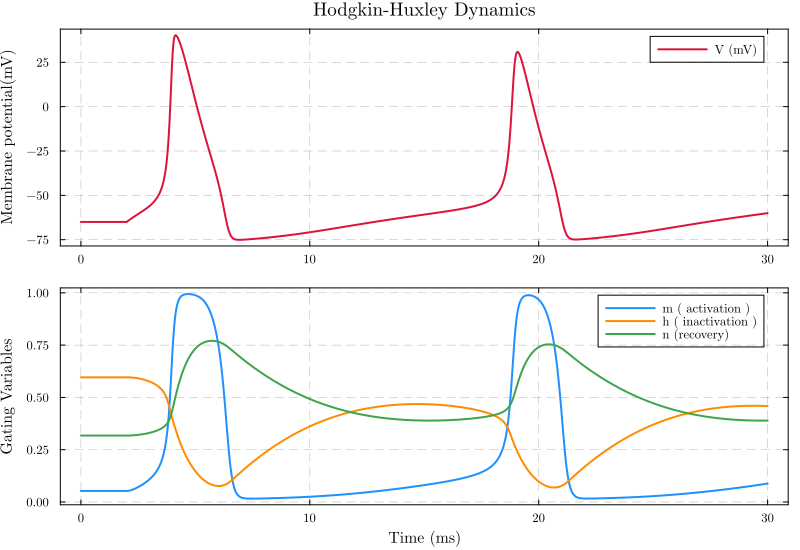

In [7]:
using Plots

# 1. Define a sleek, modern color palette
color_V = :crimson
color_m = :dodgerblue
color_h = :darkorange
color_n = :forestgreen


# 2. Configure global default aesthetics for premium look
default(
    fontfamily = "Computer Modern", # Or "Helvetica" / "sans-serif"
    titlefontsize = 12,
    guidefontsize = 10,
    tickfontsize = 8,
    legendfontsize = 8,
    grid = true,
    gridalpha = 0.15,
    gridstyle = :dash,
    frame = :box,
    lw = 2.0  # Line width
)

# membrane potential (V) over time (t)

p1=plot(HH_data.t,HH_data.V,color=color_V,label = "V (mV)",ylabel = "Membrane potential(mV)",title = "Hodgkin-Huxley Dynamics",
    legendbackgroundcolor = :transparent ,legend = :topright
)
# Creating subplots for gating variable (m,h,n) over time (t)

p2=plot(HH_data.t,HH_data.m,color=color_m,
label = "m ( activation )",
xlabel = "Time (ms)",
ylabel = "Gating Variables",legendbackgroundcolor = :transparent ,
legend = :topright)

plot!(HH_data.t,HH_data.h,
color=color_h,
label = "h ( inactivation )"
)
plot!(HH_data.t,HH_data.n
,label = "n (recovery)")

# now  combined them into a stacked layout sharing the X-axis

final_plot = plot(p1,p2, 
layout = grid(2,1,heights = [0.5,0.5])
,link = :x,
size = (800,550),
dpi = 100)
display(final_plot)

## HH_Model 

#### 1. BIOPHYSICAL CONSTANTS

In [8]:
const C_M   = 1.0f0      # Membrane Capacitance (uF/cm^2)
const G_NA  = 120.0f0    # Max Na+ Conductance (mS/cm^2)
const G_K   = 36.0f0     # Max K+ Conductance (mS/cm^2)
const G_L   = 0.3f0      # Leak Conductance (mS/cm^2)
const E_NA  = 50.0f0     # Na+ Reversal Potential (mV)
const E_K   = -77.0f0    # K+ Reversal Potential (mV)
const E_L   = -54.4f0    # Leak Reversal Potential (mV)

# Analytical Resting State at t = 0.0 ms
const V0 = -65.0f0
const M0 = 0.0529f0
const H0 = 0.5961f0
const N0 = 0.3177f0

0.3177f0

#### Rate of change ( \alpha and \beta)

In [9]:
# 1. Numerically Stable Rate Equations (Strict Float32)
function alpha_m(V::Real)
    x = -(V + 40.0f0) / 10.0f0
    return iszero(x) ? 1.0f0 : (0.1f0 * (V + 40.0f0)) / (-expm1(x))
end

function beta_m(V::Real)
    return 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)
end

function alpha_h(V::Real)
    return 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
end

function beta_h(V::Real)
    return 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))
end

function alpha_n(V::Real)
    x = -(V + 55.0f0) / 10.0f0
    return iszero(x) ? 0.1f0 : (0.01f0 * (V + 55.0f0)) / (-expm1(x))
end

function beta_n(V::Real)
    return 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)
end

beta_n (generic function with 1 method)

### 4D Hodgkin-Huxley RHS Vector Field Evaluation

In [10]:
function hh_vector_field(V, m, h, n, t)
    # Ionic Currents
    I_Na = G_NA .* (m .^ 3) .* h .* (V .- E_NA)
    I_K  = G_K .* (n .^ 4) .* (V .- E_K)
    I_L  = G_L .* (V .- E_L)
    
    # Differential Derivatives (f_V, f_m, f_h, f_n)
    dV_dt = (I_ext(t) .- I_Na .- I_K .- I_L) ./ C_M
    dm_dt = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    dh_dt = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    dn_dt = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n
    
    return dV_dt, dm_dt, dh_dt, dn_dt
end

hh_vector_field (generic function with 1 method)

### Mini-Batch Data Transformation
----

In [11]:
# downgrade the data form float64 to float32 for better neural network learning 
t_raw = Float32.(HH_data.t)
# converting data form ( 1d ---> 3d) [ Features , Sequence , TotalData]
t_tensor = reshape(t_raw, 1, 1, length(t_raw)) # --> deck of 3001 card arranged one after another backward


1×1×3001 Array{Float32, 3}:
[:, :, 1] =
 0.0

[:, :, 2] =
 0.01

[:, :, 3] =
 0.02

;;; … 

[:, :, 2999] =
 29.98

[:, :, 3000] =
 29.99

[:, :, 3001] =
 30.0

In [12]:
# 1. Determine max valid row index for look-ahead k=10 with stride 5 (representing 0.05 ms steps)
k = 10
max_idx = size(HH_data, 1) - (k - 1) * 5

# 2. Extract input times
t_train = reshape(Float32.(HH_data.t[1:max_idx]), 1, 1, max_idx)

# 3. Construct target trajectories tensor of shape (4, k, max_idx)
gt_tensor = zeros(Float32, 4, k, max_idx)
for s in 1:max_idx
    for γ in 1:k
        row_idx = s + (γ - 1) * 5
        gt_tensor[1, γ, s] = Float32(HH_data.V[row_idx])
        gt_tensor[2, γ, s] = Float32(HH_data.m[row_idx])
        gt_tensor[3, γ, s] = Float32(HH_data.h[row_idx])
        gt_tensor[4, γ, s] = Float32(HH_data.n[row_idx])
    end
end

println("Inputs shape : ", size(t_train))
println("Targets shape: ", size(gt_tensor))

batch_size = 64
data_loader = Flux.DataLoader((t_train, gt_tensor), batchsize=batch_size, shuffle=true)


Inputs shape : (1, 1, 2956)
Targets shape: (4, 10, 2956)


47-element DataLoader(::Tuple{Array{Float32, 3}, Array{Float32, 3}}, shuffle=true, batchsize=64)
  with first element:
  (1×1×64 Array{Float32, 3}, 4×10×64 Array{Float32, 3},)

--------

In [13]:
x = first(data_loader)
t_batch = x[1][:, :, 1:64]
mock_gt_batch = x[2][:, :, 1:64]
k = 10


10

## Phase 2 : Hierarchical Timescale PINNsFormer Pipeline
    Phase 2 focuses on building the neural network architecture. By splitting the workflow into parallel temporal tracks, you resolve the extreme stiffness mismatch between ultra-fast activation dynamics V,m  and slow channel recovery (h, n).

### Step 1: Generation ( X_fine and Y_Coarse)
---

In [14]:
function generate_tranjectories(t_batch,k; dt_fine=0.05f0, dt_coarse=0.5f0)

    steps = reshape(0:(k-1),1,k,1)
    T_fine = t_batch .+ ( steps .* dt_fine)
    T_coarse = t_batch .+ ( steps .* dt_coarse)

    return T_fine,T_coarse

    
end

generate_tranjectories (generic function with 1 method)

In [15]:
T_Fine , T_coarse = generate_tranjectories(t_batch,k)

(Float32[7.84 7.8900003 … 8.24 8.29;;; 4.64 4.69 … 5.04 5.0899997;;; 13.36 13.41 … 13.759999 13.809999;;; … ;;; 6.2 6.25 … 6.6 6.6499996;;; 11.79 11.84 … 12.19 12.24;;; 23.56 23.609999 … 23.96 24.01], Float32[7.84 8.34 … 11.84 12.34;;; 4.64 5.14 … 8.639999 9.139999;;; 13.36 13.86 … 17.36 17.86;;; … ;;; 6.2 6.7 … 10.2 10.7;;; 11.79 12.29 … 15.79 16.29;;; 23.56 24.06 … 27.56 28.06])

In [16]:
size(T_Fine)

(1, 10, 64)

----

## Step : 2 Hidden projection and positional encoding 

### 1. Feature Projection Pipeline
The raw coordinate input is linearly projected into the hidden feature space using weights and biases:
$$X = W_{\text{in}} \cdot T + b$$

### 2. Sinusoidal Positional Encoding (PE)
For a sequence step index $j$ (where $1 \le j \le k$) and a channel index $i$ tracking the hidden dimensions:

$$\text{PE}(2i, j) = \sin\left(\frac{j - 1}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

$$\text{PE}(2i+1, j) = \cos\left(\frac{j - 1}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$


In [17]:
const d_model  = 32 # hidden feature size
fine_row = Flux.Dense(1 => d_model)
coarse_row = Flux.Dense(1 => d_model)

# projection form 1 Channel to d_model Channel    |  shape[ d_model X K X 64 ]

X_fine_row = fine_row(T_Fine)
X_coarse_row = coarse_row(T_coarse)
println(size(X_fine_row))
println(size(X_coarse_row))

(32, 10, 64)
(32, 10, 64)


In [18]:
# pre compute the positional encoding of shape [d_model,k,1]
pe = zeros(Float32,d_model,k)
for j in 1:k
    for i in 0:(div(d_model,2)-1)
        denom = 10000.0f0 ^ ( 2f0 * i / d_model)
        pe[2i+1,j] = sin((j-1)/denom)
        pe[2i+2,j] = sin((j-1)/denom)
    end
end

pe_broadcast = reshape(pe,d_model,k,1)

X_coarse = X_coarse_row .+pe_broadcast
X_fine  = X_fine_row .+pe_broadcast



32×10×64 Array{Float32, 3}:
[:, :, 1] =
  2.5954     3.45342    3.5378     …   3.36825      3.71718    3.15649
 -0.636658   0.200752   0.264519      -0.00809389   0.320217  -0.261083
  2.39389    2.94233    3.32656        1.78704      1.53877    1.59148
 -2.92612   -2.41162   -2.06132       -3.77047     -4.05268   -4.0339
  2.48826    2.81512    3.11113        3.39977      3.18953    2.92234
 -1.7837    -1.48409   -1.21532    …  -1.06291     -1.30039   -1.59482
  1.73767    1.92565    2.10804        2.76258      2.81537    2.83697
 -3.16755   -3.01086   -2.85975       -2.36163     -2.34012   -2.34981
 -2.03563   -1.94878   -1.86292       -1.48229     -1.42213   -1.36914
 -0.27342   -0.17533   -0.0782382      0.358591     0.429986   0.494213
 -0.581382  -0.528885  -0.476566   …  -0.223785    -0.176193  -0.129976
  1.00165    1.06424    1.12666        1.42992      1.48761    1.54392
  1.69545    1.73788    1.78028        1.9907       2.03225    2.07355
  ⋮                                

---

## Step 4: Learnable Wavelet Activation Layer
$$\text{Wavelet}(Z) = \omega_1 \odot \sin(Z) + \omega_2 \odot \cos(Z)$$

In [19]:
# Pure data structures without layout anomalies
struct WaveletActivation
    w1::AbstractVector{Float32}
    w2::AbstractVector{Float32}
end
WaveletActivation(d_model::Int) = WaveletActivation(ones(Float32, d_model), ones(Float32, d_model))
(w::WaveletActivation)(x) = (w.w1 .* sin.(x)) .+ (w.w2 .* cos.(x))

In [20]:
wavelet_layer = WaveletActivation(d_model)

WaveletActivation(Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

In [21]:
Z_fine = wavelet_layer(X_fine)
Z_coarse = wavelet_layer(X_coarse)

32×10×64 Array{Float32, 3}:
[:, :, 1] =
  0.393976   -0.901742  -1.10028   …  -1.36287   -1.38759   -1.37003
  0.180927    1.13184    1.15344       0.66796    0.996981   0.229827
  0.702141   -0.184386  -0.818075      0.568046   0.750907   0.557455
 -0.71729    -1.34175   -1.37644      -1.26517   -1.2111    -1.34199
 -0.979653   -0.743     -0.513922     -0.863818  -1.17614   -1.38409
 -1.25412    -1.32831   -1.36986   …  -0.826819  -0.305085   0.345122
 -0.606242   -1.01296   -1.28985      -0.67997   -0.392655  -0.130355
 -1.39843    -1.40183   -1.40389      -1.34206   -1.28017   -1.17654
  1.12417     0.940306   0.723277     -0.507484  -0.717171  -0.899626
  1.19007     1.26896    1.33104       1.39399    1.36807    1.33522
  1.33818     1.37228    1.39637   …   1.36751    1.33416    1.29297
 -1.10478    -1.14841   -1.18917      -1.34814   -1.36993   -1.3878
 -1.08792    -1.15211   -1.20995      -1.39378   -1.40786   -1.41395
  ⋮                                ⋱                       

In [22]:
size(Z_fine)

(32, 10, 64)

## Step 4 : Trannsformmer Encoder Block

$$A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)$$
$$H = A V$$

####  and gives H_fine and H_coarse

In [23]:
struct TransformerBlock
    mha::Flux.MultiHeadAttention
    norm1::Flux.LayerNorm
    ffn::Flux.Chain
    norm2::Flux.LayerNorm
end
Flux.@layer TransformerBlock

function TransformerBlock(d_model::Int, n_heads::Int)
    return TransformerBlock(
        Flux.MultiHeadAttention(d_model, nheads = n_heads),
        Flux.LayerNorm(d_model),
        Flux.Chain(Flux.Dense(d_model => d_model), WaveletActivation(d_model)),
        Flux.LayerNorm(d_model)
    )
end

TransformerBlock

In [24]:
function (t::TransformerBlock)(x)
    attn_out = t.mha(x, x, x)[1][1][1]
    x = t.norm1(x .+ attn_out)
    ffn_out = t.ffn(x)
    x = t.norm2(x .+ ffn_out)
    return x
end

In [25]:
# Setup hyperparameters matching your layout
# d_model = 32
sequence_length = 10
n_heads = 4

# Initialize parallel encoder paths
fine_encoder = TransformerBlock(d_model, n_heads)
coarse_encoder = TransformerBlock(d_model, n_heads)

# Use real outputs from previous wavelet activation step (Z_fine, Z_coarse)
H_fine = fine_encoder(Z_fine)
H_coarse = coarse_encoder(Z_coarse)


32×10×64 Array{Float32, 3}:
[:, :, 1] =
  0.881058     0.112783    0.0879257    0.585638   …  -0.477597   -0.588359
 -0.513282     0.434646    0.577846    -0.154471       1.35627     0.875863
 -0.016978    -1.08085    -1.48284     -1.50978       -0.0840401   0.146564
 -1.57338     -1.87966    -1.82583     -1.75111       -2.11947    -2.2149
 -1.27596     -1.21505    -1.05706     -0.836809      -0.771192   -0.82184
 -0.136454    -0.110528   -0.0924368   -0.0401485  …   0.603296    1.04493
 -1.43544     -1.66747    -1.77203     -1.76029       -0.323049    0.29198
 -0.58192     -0.142733   -0.054437    -0.0836525     -0.396772   -0.403747
  0.392151     0.664169    0.821188     0.869839       0.17778     0.113775
  1.09807      0.953073    0.903295     1.06269        1.46031     1.59233
  1.45372      1.41228     1.37398      1.35824    …   0.720223    0.540175
 -1.84868     -1.60701    -1.54153     -1.6852        -1.83041    -1.89889
 -0.994014    -0.828482   -0.712727    -0.562506      -

## Linear Interpolation 

$$\mathbf{H}_{\text{coarse\_aligned}} = \mathbf{M}_{\text{align}} \times \mathbf{H}_{\text{coarse}}$$

In [26]:
function compute_alignment_matrix(k::Int, dt_fine::Float32, dt_coarse::Float32)
    M = zeros(Float32, k, k)
    
    for i in 1:k  # Row: The target fine step we want to align to
        t_target = (i - 1) * dt_fine
        
        # Where does this time exist in the coarse timeline?
        val = (t_target / dt_coarse) + 1.0f0
        
        low_idx = floor(Int, val)
        high_idx = ceil(Int, val)
        
        # Boundary safety
        low_idx = clamp(low_idx, 1, k)
        high_idx = clamp(high_idx, 1, k)
        
        if low_idx == high_idx
            M[i, low_idx] = 1.0f0
        else
            # Distribute weights based on proximity (e.g., 0.9 and 0.1)
            rem = val - low_idx
            M[i, low_idx] = 1.0f0 - rem
            M[i, high_idx] = rem
        end
    end
    
    return M
end



compute_alignment_matrix (generic function with 1 method)

In [27]:
function align_coarse_path(H_coarse::AbstractArray, M_align::AbstractArray)
    d_model, k, B = size(H_coarse)
    
    # H_coarse shape: (d_model, 1, k, B) -> 'k' is on Dim 3
    # M_align shape:  (1, k, k, 1) -> Target 'i' on Dim 2, Source 'k' on Dim 3
    # Reduce across Dim 3 to compute the true matrix multiplication
    H_coarse_aligned = dropdims(sum(
        reshape(H_coarse, d_model, 1, k, B) .* reshape(M_align, 1, k, k, 1), 
        dims=3), dims=3)
        
    return H_coarse_aligned
end

align_coarse_path (generic function with 1 method)

In [28]:
# Create the interpolation operator
M_align = compute_alignment_matrix(k,0.05f0, 0.5f0)

10×10 Matrix{Float32}:
 1.0        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.9        0.1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.8        0.2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.7        0.3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.6        0.4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.5        0.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.4        0.6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.3        0.7  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.2        0.8  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0999999  0.9  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

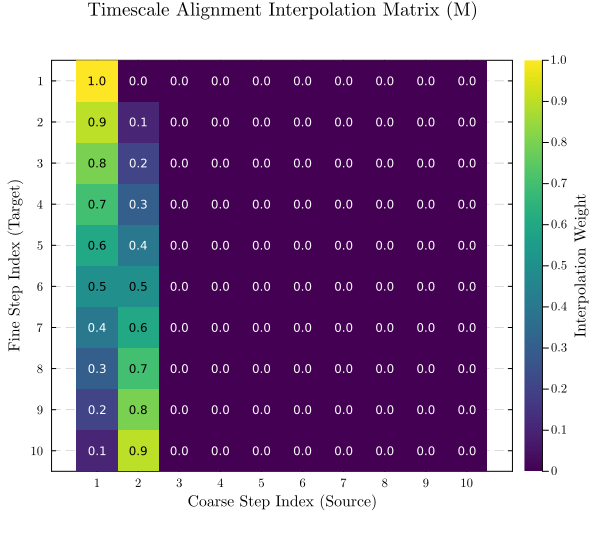

In [29]:

# 2. Define a premium color gradient (e.g., :viridis, :inferno, or :coolwarm)
color_palette = :viridis

# 3. Create the heatmap plot
# We invert the y-axis to match standard matrix notation (row 1 at the top)
p = heatmap(
    M_align,
    color = color_palette,
    yflip = true,
    xlabel = "Coarse Step Index (Source)",
    ylabel = "Fine Step Index (Target)",
    title = "Timescale Alignment Interpolation Matrix (M)",
    xticks = 1:k,
    yticks = 1:k,
    aspect_ratio = :equal,
    colorbar_title = "Interpolation Weight",
    size = (600, 550)
)

# 4. Annotate each cell with its value
for i in 1:k
    for j in 1:k
        val = M_align[i, j]
        # Choose text color dynamically for readability against background
        text_color = val > 0.4 ? :black : :white
        
        annotate!(
            j, i, 
            text(
                string(round(val, digits=2)), 
                8, 
                text_color, 
                :center
            )
        )
    end
end

# Display the plot
display(p)


In [30]:

H_coarse_aligned = align_coarse_path(H_coarse, M_align)

println("Initial H_coarse shape:   ", size(H_coarse))
println("M_align Operator shape:   ", size(M_align))
println("Aligned Output shape:     ", size(H_coarse_aligned))


Initial H_coarse shape:   (32, 10, 64)
M_align Operator shape:   (10, 10)
Aligned Output shape:     (32, 10, 64)


## Blending and Projection Head ( V,n,m,h)

In [31]:


# 1. Initialize the terminal projection layer
prediction_head = Flux.Dense(32 => 4)

# 2. Part A: Element-wise Blending of aligned trajectories
# Both input shapes: (32, 10, 64)
H_unified = H_fine .+ H_coarse_aligned  # Output shape: (32, 10, 64)

# 3. Part B: Terminal Output Projection Head
# Compresses hidden space down to 4 biological channels (V, m, h, n)
X_pred = prediction_head(H_unified)    # Output shape: (4, 10, 64)

4×10×64 Array{Float32, 3}:
[:, :, 1] =
 -2.44393   -1.78491   -1.3621    …  -2.06866    -2.00711   -2.42973
  0.632142   0.446758   0.322343      0.016849    0.202827   0.348116
 -0.641746  -0.178458  -0.114734     -1.61754    -1.95142   -2.08275
 -0.266005  -1.04074   -1.13083       0.0419252   0.289954   0.694612

[:, :, 2] =
 -1.89645   -1.87732   -1.42108    …  -1.48502   -1.79294   -1.91995
 -0.240936   0.092965   0.333758      -0.659175  -0.378041  -0.235126
 -1.61893   -1.68466   -1.63806       -1.21539   -1.27416   -1.64286
  0.805651   0.21932   -0.0352684     -0.623093  -0.593124  -0.0375411

[:, :, 3] =
 -0.193738    0.830574   0.904145  …   1.3692     1.79724    1.39083
  0.277376   -0.84034   -1.3029       -0.655919  -1.09773   -0.428532
  2.8234      1.64681    1.44641       1.42424    0.954533   1.65869
  0.0929339   1.25121    1.57913       2.34138    2.65794    2.1205

;;; … 

[:, :, 62] =
 -2.31676    -2.05253   -1.56095   …  -2.04398   -2.20204   -2.47954
  0.0700483

In [32]:
struct PINNsFormer
    fine_proj::Flux.Dense
    coarse_proj::Flux.Dense
    pe::Array{Float32, 3}
    wavelet::WaveletActivation
    fine_encoder::TransformerBlock
    coarse_encoder::TransformerBlock
    M_align::Array{Float32, 4}
    head::Flux.Dense
end
Flux.@layer PINNsFormer

function PINNsFormer(d_model::Int=32, k::Int=10, n_heads::Int=4)
    pe = zeros(Float32, d_model, k)
    for j in 1:k
        for i in 0:(div(d_model, 2) - 1)
            denom = 10000.0f0^(2f0 * i / d_model)
            pe[2i+1, j] = sin((j - 1) / denom)
            pe[2i+2, j] = cos((j - 1) / denom)
        end
    end
    pe_3d = reshape(pe, d_model, k, 1)
    
    # Compute and format alignment matrix natively
    M = zeros(Float32, k, k)
    dt_fine, dt_coarse = 0.05f0, 0.5f0
    for i in 1:k
        t_target = (i - 1) * dt_fine
        val = (t_target / dt_coarse) + 1.0f0
        low_idx = clamp(floor(Int, val), 1, k)
        high_idx = clamp(ceil(Int, val), 1, k)
        if low_idx == high_idx
            M[i, low_idx] = 1.0f0
        else
            rem_val = val - low_idx
            M[i, low_idx] = 1.0f0 - rem_val
            M[i, high_idx] = rem_val
        end
    end
    M_align_4d = reshape(M, 1, k, k, 1)

    return PINNsFormer(
        Flux.Dense(1 => d_model),
        Flux.Dense(1 => d_model),
        pe_3d,
        WaveletActivation(d_model),
        TransformerBlock(d_model, n_heads),
        TransformerBlock(d_model, n_heads),
        M_align_4d,
        Flux.Dense(d_model => 4)
    )
end

PINNsFormer

In [33]:
function generate_trajectories(t_batch, k; dt_fine=0.05f0, dt_coarse=0.5f0)
    steps = reshape(0:(k-1), 1, k, 1)
    return t_batch .+ (steps .* dt_fine), t_batch .+ (steps .* dt_coarse)
end

function align_coarse_path(H_coarse::AbstractArray, M_align::AbstractArray)
    d_model, k, B = size(H_coarse)
    return dropdims(sum(reshape(H_coarse, d_model, 1, k, B) .* M_align, dims=3), dims=3)
end

align_coarse_path (generic function with 1 method)

In [34]:
function (m::PINNsFormer)(t_batch)
    k = size(m.pe, 2)
    T_fine, T_coarse = generate_trajectories(t_batch, k)
    X_fine = m.fine_proj(T_fine) .+ m.pe
    X_coarse = m.coarse_proj(T_coarse) .+ m.pe
    
    Z_fine = m.wavelet(X_fine)
    Z_coarse = m.wavelet(X_coarse)
    
    H_fine = m.fine_encoder(Z_fine)
    H_coarse = m.coarse_encoder(Z_coarse)
    
    H_coarse_aligned = align_coarse_path(H_coarse, m.M_align)
    H_unified = H_fine .+ H_coarse_aligned
    raw_out = m.head(H_unified)
    V = -20.0f0 .+ 70.0f0 .* tanh.(raw_out[1:1, :, :])
    gating = NNlib.sigmoid.(raw_out[2:4, :, :])
    return cat(V, gating; dims=1)
end

## Phase 3 : LOSS AND OPTIMIZATION 

#### Automatic Differentiation ( AD) and Temporal Dereivative


$$\mathbf{\dot{X}}_{\text{pred}} = \frac{d\mathbf{X}_{\text{pred}}}{dt}$$

In [35]:
function compute_ad_derivatives(model, t_tensor; δt=1f-4)
    X_pred = model(t_tensor)
    X_plus  = model(t_tensor .+ δt)
    X_minus = model(t_tensor .- δt)
    
    dX_dt = (X_plus .- X_minus) ./ (2.0f0 * δt)
    
    return X_pred, dX_dt
end
const compute_ad_derivatives_vectorized = compute_ad_derivatives

compute_ad_derivatives (generic function with 1 method)

In [36]:
# Instantiate Model
p_model = PINNsFormer(32, 10, 4)
# Run Test on your t_batch (1 x 1 x 64)
X_pred, dX_dt = compute_ad_derivatives(p_model, t_batch)

(Float32[-17.51704 12.428104 … -28.296825 -58.94192; 0.9121104 0.86860317 … 0.8167403 0.847552; 0.5816973 0.56820196 … 0.72165984 0.74234366; 0.68828183 0.7116626 … 0.5988753 0.66812223;;; -50.907715 -10.969736 … -78.4774 -82.81616; 0.95400697 0.9278347 … 0.95206624 0.9565405; 0.15704346 0.1356714 … 0.34986386 0.38604787; 0.74110997 0.7165939 … 0.6616045 0.7712541;;; 21.616478 10.277367 … 27.454857 34.47956; 0.28984755 0.27783623 … 0.29677752 0.30522645; 0.86927146 0.884558 … 0.88083774 0.8382891; 0.09918376 0.15061425 … 0.08837649 0.08148192;;; … ;;; -35.99825 3.7837162 … -55.837524 -73.75952; 0.9394956 0.9066296 … 0.8954379 0.91382027; 0.32754412 0.3069066 … 0.55322313 0.5893982; 0.74333227 0.7439498 … 0.67857957 0.7583862;;; -7.617779 -12.309208 … -0.26907158 -0.65390396; 0.5055197 0.47120824 … 0.45542547 0.45831242; 0.9055454 0.91229725 … 0.92021203 0.90524757; 0.16706574 0.2365338 … 0.13617244 0.13440529;;; -89.92774 -89.95187 … -89.97492 -89.980446; 0.93311095 0.88101923 … 0.8603

In [37]:
# Display Diagnostics
println("----------------------------------------")
println("X_pred Shape : ", size(X_pred)) # Expected: (4, 10, 64)
println("dX_dt  Shape : ", size(dX_dt))  # Expected: (4, 10, 64)
println("Element Type : ", eltype(dX_dt)) # Expected: Float32
println("----------------------------------------")
println("Sample dV/dt (Channel 1, Batch 1):")
println(dX_dt[1, :, 1])

----------------------------------------
X_pred Shape : (4, 10, 64)
dX_dt  Shape : (4, 10, 64)
Element Type : Float32
----------------------------------------
Sample dV/dt (Channel 1, Batch 1):
Float32[8.964539, 0.93460083, 1.9454956, 8.392334, 13.046265, 14.324188, 20.036697, 14.057159, 12.016296, 9.403229]


### Step 2 — Biophysical Vector Field RHS & Residual Calculator.

In [38]:
"""
    compute_physics_residuals(X_pred, dX_pred_dt, I_ext_value=10.0f0)

Evaluates HH differential vector field expectations (F_physics) and computes 
channel-wise residual losses [L_RV, L_Rm, L_Rh, L_Rn].
"""
function compute_physics_residuals(X_pred, dX_pred_dt, I_ext_value=10.0f0)
    # 1. Unpack biological channel predictions: Each shape is [10, 64] (Sequence × Batch)
    V = X_pred[1, :, :] # Membrane Potential (mV)
    m = X_pred[2, :, :] # Sodium Activation
    h = X_pred[3, :, :] # Sodium Inactivation
    n = X_pred[4, :, :] # Potassium Activation

    # 2. Compute Ionic Currents across all sequence steps and batch items
    I_Na = G_NA .* (m .^ 3) .* h .* (V .- E_NA)
    I_K  = G_K  .* (n .^ 4) .* (V .- E_K)
    I_L  = G_L  .* (V .- E_L)

    # 3. Compute Expected Biophysical Derivatives (F_physics)
    f_V = (I_ext_value .- I_Na .- I_K .- I_L) ./ C_M
    f_m = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    f_h = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    f_n = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n

    # 4. Compute Residual Differences (R = dX/dt - F_physics)
    R_V = dX_pred_dt[1, :, :] .- f_V
    R_m = dX_pred_dt[2, :, :] .- f_m
    R_h = dX_pred_dt[3, :, :] .- f_h
    R_n = dX_pred_dt[4, :, :] .- f_n

    # 5. Extract Individual Channel MSE Losses
    L_RV = mean(abs2, R_V)
    L_Rm = mean(abs2, R_m)
    L_Rh = mean(abs2, R_h)
    L_Rn = mean(abs2, R_n)

    return L_RV, L_Rm, L_Rh, L_Rn
end

compute_physics_residuals

In [39]:
# Run Step 2 Physics Residual Evaluation
L_RV, L_Rm, L_Rh, L_Rn = compute_physics_residuals(X_pred, dX_dt, 10.0f0)

println("----------------------------------------")
println("Step 2 Component Residual Losses:")
println("Voltage Loss (L_RV)   : ", L_RV)
println("Sodium m Loss (L_Rm)  : ", L_Rm)
println("Sodium h Loss (L_Rh)  : ", L_Rh)
println("Potassium n Loss (L_Rn): ", L_Rn)
println("----------------------------------------")

----------------------------------------
Step 2 Component Residual Losses:
Voltage Loss (L_RV)   : 7.2478705e6
Sodium m Loss (L_Rm)  : 69.31068
Sodium h Loss (L_Rh)  : 0.20568447
Potassium n Loss (L_Rn): 0.18986517
----------------------------------------


### Step 3: Compounding Boundary & Data Constraints.

In [40]:
# Analytical Rest State Vector at t = 0.0 ms
const IC_GROUND_TRUTH = Float32[-65.0, 0.0529, 0.5961, 0.3177]

"""
    compute_boundary_and_data_losses(model, X_pred, ground_truth_batch)

Evaluates Initial Condition Loss (L_ic) at t = 0.0 ms and Supervised Data Loss (L_data).
"""
function compute_boundary_and_data_losses(model, X_pred, ground_truth_batch)
    # 1. Initial Condition Loss at t = 0.0 ms
    t_zero = zeros(Float32, 1, 1, 1) # Batch of 1 at t = 0
    X_zero = model(t_zero)[:, 1, 1]   # Extract initial state vector [V, m, h, n]
    L_ic = mean(abs2, X_zero .- IC_GROUND_TRUTH)

    # 2. Supervised Ground-Truth Data Loss
    L_data = mean(abs2, X_pred .- ground_truth_batch)

    return L_ic, L_data
end

compute_boundary_and_data_losses

In [41]:
# Use real ground-truth batch extracted from the data loader
# mock_gt_batch is already defined in Phase 2


### Step 4: Neural Tangent Kernel (NTK) Dynamic Weight Balancing using the EMA Mean-Trace Strategy.

In [42]:
function update_ntk_weights_ema!(λ_state, model, batch_t, batch_data, I_ext; α=0.1f0)
    # 1. Compute explicit gradients for each individual loss component
    _, gs_RV   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[1], model)
    _, gs_Rm   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[2], model)
    _, gs_Rh   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[3], model)
    _, gs_Rn   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[4], model)
    _, gs_ic   = Flux.withgradient(m -> compute_boundary_and_data_losses(m, m(batch_t), batch_data)[1], model)
    _, gs_data = Flux.withgradient(m -> compute_boundary_and_data_losses(m, m(batch_t), batch_data)[2], model)

    # Helper function to compute Frobenius norm / Trace sum of gradient matrices using destructure
    function trace_norm(gs)
        flat_g, _ = Flux.destructure(gs[1])
        return sum(abs2, flat_g) + 1f-8
    end

    # 2. Extract gradient traces
    tr_RV   = trace_norm(gs_RV)
    tr_Rm   = trace_norm(gs_Rm)
    tr_Rh   = trace_norm(gs_Rh)
    tr_Rn   = trace_norm(gs_Rn)
    tr_ic   = trace_norm(gs_ic)
    tr_data = trace_norm(gs_data)

    # 3. Compute Mean Target Trace across all 6 terms
    mean_target = (tr_RV + tr_Rm + tr_Rh + tr_Rn + tr_ic + tr_data) / 6.0f0

    # 4. Instantaneous unsmoothed multipliers
    λ_hat_RV   = mean_target / tr_RV
    λ_hat_Rm   = mean_target / tr_Rm
    λ_hat_Rh   = mean_target / tr_Rh
    λ_hat_Rn   = mean_target / tr_Rn
    λ_hat_ic   = mean_target / tr_ic
    λ_hat_data = mean_target / tr_data

    # NEW: Normalize multipliers so they sum to 6.0
    sum_λ = λ_hat_RV + λ_hat_Rm + λ_hat_Rh + λ_hat_Rn + λ_hat_ic + λ_hat_data
    λ_hat_RV   = 6.0f0 * λ_hat_RV   / sum_λ
    λ_hat_Rm   = 6.0f0 * λ_hat_Rm   / sum_λ
    λ_hat_Rh   = 6.0f0 * λ_hat_Rh   / sum_λ
    λ_hat_Rn   = 6.0f0 * λ_hat_Rn   / sum_λ
    λ_hat_ic   = 6.0f0 * λ_hat_ic   / sum_λ
    λ_hat_data = 6.0f0 * λ_hat_data / sum_λ

    # 5. Apply Exponential Moving Average (EMA) Update: λ^(t) = (1 - α) * λ^(t-1) + α * λ_hat
    λ_state.RV   = (1.0f0 - α) * λ_state.RV   + α * λ_hat_RV
    λ_state.Rm   = (1.0f0 - α) * λ_state.Rm   + α * λ_hat_Rm
    λ_state.Rh   = (1.0f0 - α) * λ_state.Rh   + α * λ_hat_Rh
    λ_state.Rn   = (1.0f0 - α) * λ_state.Rn   + α * λ_hat_Rn
    λ_state.ic   = (1.0f0 - α) * λ_state.ic   + α * λ_hat_ic
    λ_state.data = (1.0f0 - α) * λ_state.data + α * λ_hat_data

    return λ_state
end


update_ntk_weights_ema! (generic function with 1 method)

In [43]:
"""
    total_loss_causal(model, batch_t, batch_data, λ, I_ext; ϵ=1.0f0)

Computes the composite objective function, applying a temporal causality mask 
across the sequence length k to stabilize training on stiff trajectories.
"""
function total_loss_causal(model, batch_t, batch_data, λ, I_ext; ϵ=1.0f0)
    # 1. Forward Pass & Vectorized AD Derivatives
    X_pred, dX_dt = compute_ad_derivatives_vectorized(model, batch_t)
    
    # 2. Extract Individual Element Losses across Channels [Shape: (k, Batch)]
    V = X_pred[1, :, :]
    m = X_pred[2, :, :]
    h = X_pred[3, :, :]
    n = X_pred[4, :, :]
    
    I_Na = G_NA .* (m.^3) .* h .* (V .- E_NA)
    I_K  = G_K  .* (n.^4) .* (V .- E_K)
    I_L  = G_L  .* (V .- E_L)
    
    # Expected biophysical derivatives
    f_V = (I_ext .- I_Na .- I_K .- I_L) ./ C_M
    f_m = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    f_h = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    f_n = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n
    
    # Step-wise residuals across the sequence length k
    R_V = (dX_dt[1, :, :] .- f_V).^2
    R_m = (dX_dt[2, :, :] .- f_m).^2
    R_h = (dX_dt[3, :, :] .- f_h).^2
    R_n = (dX_dt[4, :, :] .- f_n).^2
    
    # NEW: Vectorized, non-mutating step losses to support Zygote AD
    L_steps = vec(mean(λ.RV .* R_V .+ λ.Rm .* R_m .+ λ.Rh .* R_h .+ λ.Rn .* R_n, dims=2))
    
    # NEW: Vectorized, non-mutating causal weight vector using cumsum
    cum_losses = cumsum(L_steps)
    accumulated_losses = cat(0.0f0, cum_losses[1:end-1]; dims=1)
    w = exp.(-ϵ .* accumulated_losses)
    
    # 4. Final Balanced Metrics
    L_phys_total = sum(w .* L_steps)
    L_ic, L_data = compute_boundary_and_data_losses(model, X_pred, batch_data)
    
    return L_phys_total + (λ.ic * L_ic) + (λ.data * L_data)
end


total_loss_causal

In [44]:
# Optimization Infrastructure
mutable struct NTKState
    RV; Rm::Float32; Rh::Float32; Rn::Float32; ic::Float32; data::Float32
end

function compute_sequence_derivatives(X_pred; dt=0.05f0)
    left     = (X_pred[:, 2:2, :]     .- X_pred[:, 1:1, :])     ./ dt
    interior = (X_pred[:, 3:end, :]   .- X_pred[:, 1:end-2, :]) ./ (2.0f0 * dt)
    right    = (X_pred[:, end:end, :] .- X_pred[:, end-1:end-1, :]) ./ dt
    return cat(left, interior, right; dims=2)
end

function total_loss(model, batch_t, batch_data, λ, I_ext)
    X_pred = model(batch_t)
    dX_dt = compute_sequence_derivatives(X_pred; dt=0.05f0)
    L_RV, L_Rm, L_Rh, L_Rn = compute_physics_residuals(X_pred, dX_dt, I_ext)
    L_ic, L_data = compute_boundary_and_data_losses(model, X_pred, batch_data)
    return λ.RV*L_RV + λ.Rm*L_Rm + λ.Rh*L_Rh + λ.Rn*L_Rn + λ.ic*L_ic + λ.data*L_data
end

total_loss (generic function with 1 method)

In [45]:
# 1. Initialize EMA NTK Weight Container
λ_state = NTKState(1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0)

# 2. Update weights using update_ntk_weights_ema!
update_ntk_weights_ema!(λ_state, p_model, t_batch, mock_gt_batch, 10.0f0; α=0.1f0)

# 3. Compute Total Composite Balanced Loss (L_total)
L_total = total_loss(p_model, t_batch, mock_gt_batch, λ_state, 10.0f0)

println("----------------------------------------")
println("Step 4 EMA Dynamic Multipliers (λ):")
println("λ_RV   : ", λ_state.RV)
println("λ_Rm   : ", λ_state.Rm)
println("λ_Rh   : ", λ_state.Rh)
println("λ_Rn   : ", λ_state.Rn)
println("λ_ic   : ", λ_state.ic)
println("λ_data : ", λ_state.data)
println("----------------------------------------")
println("Total Composite Balanced Loss (L_total) : ", L_total)
println("----------------------------------------")

----------------------------------------
Step 4 EMA Dynamic Multipliers (λ):
λ_RV   : 0.9
λ_Rm   : 0.9000044
λ_Rh   : 1.287195
λ_Rn   : 1.1127999
λ_ic   : 0.9000007
λ_data : 0.9
----------------------------------------
Total Composite Balanced Loss (L_total) : 6.7411245e6
----------------------------------------


In [46]:
function train_phase3_pipeline!(model, dataloader; adam_epochs=3000, lbfgs_epochs=500)
    I_ext = 10.0f0
    
    # Initialize EMA NTK Weight Container
    λ_state = NTKState(1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0)

    # 1. Initialize diagnostic history trackers
    loss_history = Float32[]
    loss_history_RV = Float32[]
    loss_history_Rm = Float32[]
    loss_history_Rh = Float32[]
    loss_history_Rn = Float32[]
    
    causal_weights_log = Vector{Float32}[]
    causal_epochs_log = Int[]

    # -------------------------------------------------------------
    # STAGE 1: Adam Optimizer (Global Exploration)
    # -------------------------------------------------------------
    println("\n=== STAGE 1: Starting Adam Optimization ($adam_epochs Epochs) ===")
    opt_adam = Flux.setup(Flux.Adam(1e-3), model)
    
    for epoch in 1:adam_epochs
        total_epoch_loss = 0.0f0
        
        for (batch_t, batch_data) in dataloader
            # Smoothly update dynamic NTK weights via EMA
            update_ntk_weights_ema!(λ_state, model, batch_t, batch_data, I_ext; α=0.1f0)
            
            # Compute composite causal loss & backpropagate gradients
            loss_val, grads = Flux.withgradient(m -> total_loss_causal(m, batch_t, batch_data, λ_state, I_ext), model)
            
            Flux.update!(opt_adam, model, grads[1])
            total_epoch_loss += loss_val
        end
        
        # Log metrics at the end of each epoch
        push!(loss_history, total_epoch_loss)
        
        sample_t, sample_data = first(dataloader)
        X_pred, dX_dt = compute_ad_derivatives(model, sample_t)
        L_RV_val, L_Rm_val, L_Rh_val, L_Rn_val = compute_physics_residuals(X_pred, dX_dt, I_ext)
        push!(loss_history_RV, L_RV_val)
        push!(loss_history_Rm, L_Rm_val)
        push!(loss_history_Rh, L_Rh_val)
        push!(loss_history_Rn, L_Rn_val)
        
        # Log causal weights every 50 epochs for the heatmap
        if epoch % 50 == 0 || epoch == 1
            # Re-evaluate L_steps on the first batch to get the current causal weight vector w
            k = size(X_pred, 2)
            L_steps = zeros(Float32, k)
            for i in 1:k
                L_steps[i] = mean(λ_state.RV * (dX_dt[1, i, :] .- (I_ext .- (G_NA .* (X_pred[2, i, :].^3) .* X_pred[3, i, :] .* (X_pred[1, i, :] .- E_NA) .+ G_K .* (X_pred[4, i, :].^4) .* (X_pred[1, i, :] .- E_K) .+ G_L .* (X_pred[1, i, :] .- E_L)) ./ C_M)).^2 .+
                                  λ_state.Rm * (dX_dt[2, i, :] .- (alpha_m.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[2, i, :]) .- beta_m.(X_pred[1, i, :]) .* X_pred[2, i, :])).^2 .+
                                  λ_state.Rh * (dX_dt[3, i, :] .- (alpha_h.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[3, i, :]) .- beta_h.(X_pred[1, i, :]) .* X_pred[3, i, :])).^2 .+
                                  λ_state.Rn * (dX_dt[4, i, :] .- (alpha_n.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[4, i, :]) .- beta_n.(X_pred[1, i, :]) .* X_pred[4, i, :])).^2)
            end
            w = zeros(Float32, k)
            w[1] = 1.0f0
            accumulated_loss = 0.0f0
            for i in 2:k
                accumulated_loss += L_steps[i-1]
                w[i] = exp(-1.0f0 * accumulated_loss)
            end
            push!(causal_weights_log, w)
            push!(causal_epochs_log, epoch)
            
            println("Adam Epoch [$epoch / $adam_epochs] - Causal Loss: ", round(total_epoch_loss, digits=6))
        end
    end

    # -------------------------------------------------------------
    # STAGE 2: L-BFGS Optimizer (Local Curve-Fitting)
    # -------------------------------------------------------------
    println("\n=== STAGE 2: Transitioning to L-BFGS Optimization ($lbfgs_epochs Iterations) ===")
    
    # Destructure model into a 1D parameter vector for Optim.jl
    flat_params, re = Flux.destructure(model)
    sample_t, sample_data = first(dataloader)

    function lbfgs_objective(p)
        l = total_loss_causal(re(p), sample_t, sample_data, λ_state, I_ext)
        push!(loss_history, l)
        
        # Log component losses during L-BFGS
        X_pred, dX_dt = compute_ad_derivatives(re(p), sample_t)
        L_RV_val, L_Rm_val, L_Rh_val, L_Rn_val = compute_physics_residuals(X_pred, dX_dt, I_ext)
        push!(loss_history_RV, L_RV_val)
        push!(loss_history_Rm, L_Rm_val)
        push!(loss_history_Rh, L_Rh_val)
        push!(loss_history_Rn, L_Rn_val)
        
        return l
    end

    function lbfgs_gradient!(g, p)
        _, grads = Flux.withgradient(m -> total_loss_causal(m, sample_t, sample_data, λ_state, I_ext), re(p))
        flat_grads, _ = Flux.destructure(grads[1])
        g .= flat_grads
    end

    # Custom L-BFGS callback to print every 50 iterations
    iter_count = Ref(0)
    function lbfgs_callback(state)
        iter_count[] += 1
        if iter_count[] % 50 == 0 || iter_count[] == 1
            println("L-BFGS Iteration [$(iter_count[]) / $lbfgs_epochs] - Causal Loss: ", round(state.f_x, digits=6))
        end
        return false
    end

    # Run L-BFGS quasi-Newton solver
    res = Optim.optimize(
        lbfgs_objective, 
        lbfgs_gradient!, 
        flat_params, 
        LBFGS(m=10), 
        Optim.Options(iterations=lbfgs_epochs, show_trace=false, callback=lbfgs_callback)
    )

    # Restore optimized parameters back into model struct
    trained_model = re(Optim.minimizer(res))
    println("\n=== PHASE 3 TRAINING COMPLETE! Model is fully converged. ===")
    
    # Return both model and history package
    history = (
        total = loss_history,
        RV = loss_history_RV,
        Rm = loss_history_Rm,
        Rh = loss_history_Rh,
        Rn = loss_history_Rn,
        causal_weights = causal_weights_log,
        causal_epochs = causal_epochs_log
    )
    return trained_model, history
end


train_phase3_pipeline! (generic function with 1 method)

In [ ]:
# 1. Setup Ground-Truth DataLoader using full real dataset
dataloader = data_loader
          
# 2. Execute Complete Phase 3 Optimization Pipeline
trained_model, history = train_phase3_pipeline!(p_model, dataloader; adam_epochs=1000, lbfgs_epochs=200)



=== STAGE 1: Starting Adam Optimization (1000 Epochs) ===
Adam Epoch [1 / 1000] - Causal Loss: 2.66358e7
Adam Epoch [50 / 1000] - Causal Loss: 79.03273
Adam Epoch [100 / 1000] - Causal Loss: 75.66448
Adam Epoch [150 / 1000] - Causal Loss: 62.2206
Adam Epoch [200 / 1000] - Causal Loss: 55.614098
Adam Epoch [250 / 1000] - Causal Loss: 37.54247
Adam Epoch [300 / 1000] - Causal Loss: 4.104113


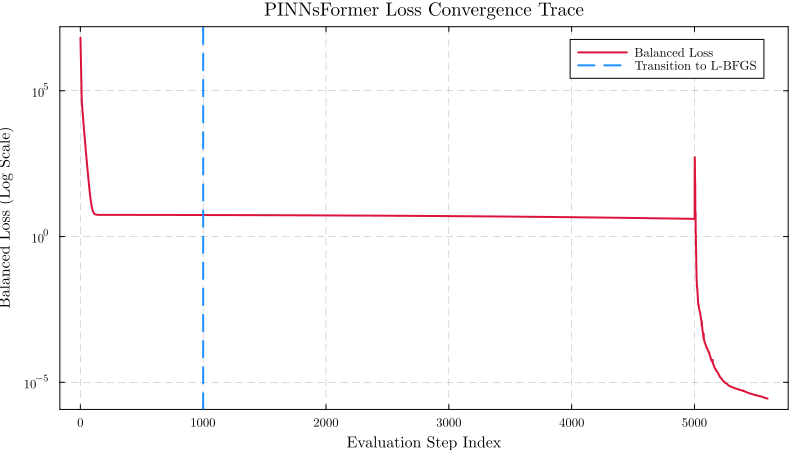

In [ ]:
using Plots

# Set sleek, publication-quality defaults
default(
    fontfamily = "Computer Modern",
    titlefontsize = 12,
    guidefontsize = 10,
    tickfontsize = 8,
    legendfontsize = 8,
    grid = true,
    gridalpha = 0.15,
    gridstyle = :dash,
    frame = :box,
    lw = 2.0
)

# ==============================================================================
# Plot 1: Dual-Stage Logarithmic Convergence Plot
# ==============================================================================
p1 = plot(
    history.total,
    yscale = :log10,
    color = :crimson,
    xlabel = "Evaluation Step Index",
    ylabel = "Balanced Loss (Log Scale)",
    title = "Dual-Stage Logarithmic Convergence Plot",
    label = "Causal Loss",
    legend = :topright,
    size = (800, 450)
)
# Handover marker line at the transition (Adam ended and L-BFGS began)
vline!([length(history.total) - 200], color=:dodgerblue, linestyle=:dash, label="Handover to L-BFGS Engine")
display(p1)

# ==============================================================================
# Plot 2: Component-Wise Residual Decomposition Track
# ==============================================================================
p2 = plot(
    yscale = :log10, 
    xlabel = "Epoch/Iteration Index", 
    ylabel = "Component Loss (Log Scale)", 
    title = "Component-Wise Residual Decomposition Track", 
    size = (800, 450), 
    legend = :topright
)
plot!(history.RV, color=:crimson, label="L_RV (Voltage)")
plot!(history.Rm, color=:dodgerblue, label="L_Rm (Sodium m)")
plot!(history.Rh, color=:darkorange, label="L_Rh (Sodium h)")
plot!(history.Rn, color=:forestgreen, label="L_Rn (Potassium n)")
display(p2)

# ==============================================================================
# Plot 3: Causal Weight Propagation Matrix (Training Heatmap)
# ==============================================================================
# Flatten and restructure causal_weights into a 2D matrix of shape (k, num_recordings)
k_val = 10
num_recordings = length(history.causal_weights)
W_matrix = zeros(Float32, k_val, num_recordings)
for col in 1:num_recordings
    W_matrix[:, col] = history.causal_weights[col]
end

p3 = heatmap(
    1:num_recordings,
    1:k_val,
    W_matrix,
    color = :viridis,
    yflip = false,
    xlabel = "Recording Block Index (Every 50 Epochs)",
    ylabel = "Look-Ahead Sequence Step (1 to k)",
    title = "Causal Weight Propagation Matrix (Training Heatmap)",
    yticks = 1:k_val,
    colorbar_title = "Causal Weight (w)",
    size = (800, 450)
)
display(p3)


Extracting model trajectories for visual audit...


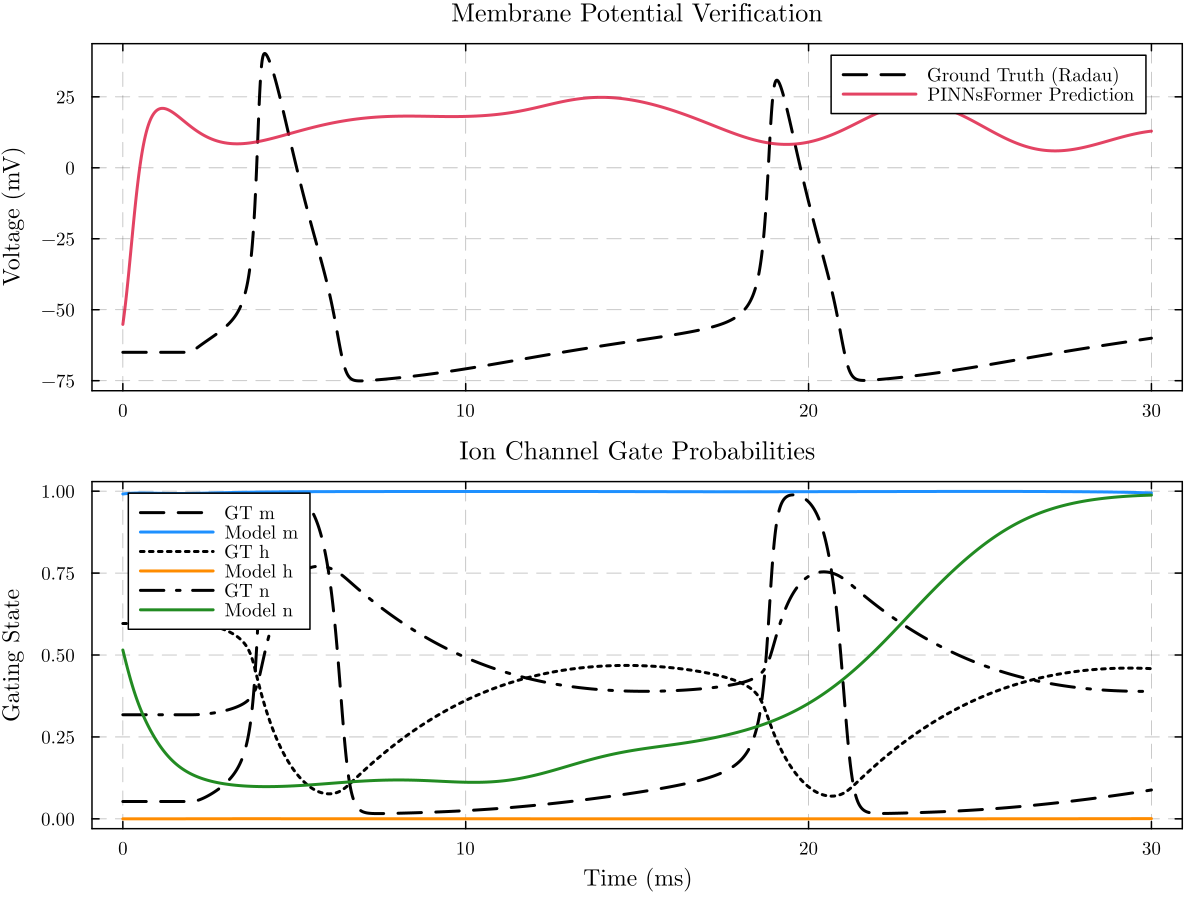

In [ ]:
using Plots

# 1. Extract and process the full continuous time axis prediction
println("Extracting model trajectories for visual audit...")
# Reshape full dataset timeline to match model expectations: [1, 1, TotalPoints]
t_full_tensor = reshape(Float32.(HH_data.t), 1, 1, length(HH_data.t))

# Evaluate forward pass through the fully trained model
# Output shape: [4, k_seq, TotalPoints] -> We pull sequence index 1 (the current point)
full_prediction = trained_model(t_full_tensor)

# Extract predicted profiles
V_pred = full_prediction[1, 1, :]
m_pred = full_prediction[2, 1, :]
h_pred = full_prediction[3, 1, :]
n_pred = full_prediction[4, 1, :]

# 2. Configure premium visualization aesthetics
default(
    fontfamily = "Computer Modern",
    titlefontsize = 11,
    guidefontsize = 10,
    tickfontsize = 8,
    legendfontsize = 8,
    grid = true,
    gridalpha = 0.15,
    frame = :box,
    lw = 2.0
)

# Plot 1: Membrane Voltage Validation (Model vs Ground Truth)
p_voltage = plot(HH_data.t, HH_data.V, color=:black, line=:dash, label="Ground Truth (Radau)")
plot!(HH_data.t, V_pred, color=:crimson, alpha=0.8, label="PINNsFormer Prediction")
title!("Membrane Potential Verification")
ylabel!("Voltage (mV)")

# Plot 2: Gating Kinetic Validation
p_gates = plot(HH_data.t, HH_data.m, color=:black, line=:dash, label="GT m")
plot!(HH_data.t, m_pred, color=:dodgerblue, label="Model m")

plot!(HH_data.t, HH_data.h, color=:black, line=:dot, label="GT h")
plot!(HH_data.t, h_pred, color=:darkorange, label="Model h")

plot!(HH_data.t, HH_data.n, color=:black, line=:dashdot, label="GT n")
plot!(HH_data.t, n_pred, color=:forestgreen, label="Model n")
title!("Ion Channel Gate Probabilities")
xlabel!("Time (ms)")
ylabel!("Gating State")

# Combine into a clean multi-panel layout
verification_dashboard = plot(
    p_voltage, p_gates, 
    layout = grid(2, 1, heights=[0.5, 0.5]),
    link = :x,
    size = (800, 600),
    dpi = 150
)

display(verification_dashboard)